# From-Scratch Mini LLM: Pre-training and Sentiment Transfer

This notebook is a guided tour of the pipeline. The model is a compact,
from-scratch decoder-only LM inspired by the Qwen3 family (RMSNorm, RoPE, SwiGLU,
grouped-query capable attention), not a reproduction of Qwen at scale. Every code cell imports from the
`qwen3_pipeline` package and either calls package functions or reads the committed
summary artifacts under `artifacts/`; none of the modeling logic is duplicated here.

The heavy stages (data download, pre-training, classifier training) are run from the
command line (`python qwen3_pipeline.py ...`). Here we inspect the architecture, show
tokenization, and display the committed metrics and figures from the reference run.

Phases:
1. Architecture
2. Tokenization
3. Data preparation
4. Pre-training
5. Generation
6. Sentiment classification (frozen probe)
7. Baselines and comparison
8. Tokenizer coverage and error analysis
9. Summary

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display

import qwen3_pipeline as qp

ARTIFACTS = qp.ARTIFACTS_DIR
FIGURES = qp.FIGURES_DIR


def load_artifact(name):
    """Read a committed summary JSON from the artifacts directory."""
    with open(ARTIFACTS / name) as f:
        return json.load(f)

print("Package version:", qp.__version__)

Package version: 1.0.0


## Phase 1: Architecture

The model is a decoder-only transformer built from scratch with RMSNorm, rotary
position embeddings, SwiGLU feed-forward blocks, and tied input/output embeddings.
Building it with the canonical configuration reports the realized parameter count.

In [2]:
summary = load_artifact("model_summary.json")
arch = summary["config"]

config = qp.default_model_config(arch["vocab_size"], arch["max_seq_len"])
model = qp.Qwen3Model(config)
counts = model.count_parameters()

print(f"Parameters: {counts['actual_total']:,} ({counts['actual_millions']:.2f}M)")
print(f"Layers: {arch['num_layers']}, d_model: {arch['d_model']}, "
      f"heads: {arch['num_heads']}, FFN: {arch['intermediate_size']}")
print(f"Committed summary reports: {summary['parameters_total']:,} parameters")

Initialized Qwen3-small with 19.52M parameters
Parameters: 19,520,000 (19.52M)
Layers: 6, d_model: 512, heads: 8, FFN: 1024
Committed summary reports: 19,520,000 parameters


## Phase 2: Tokenization

A word-level tokenizer is trained from scratch on the corpus. Special tokens take
IDs 0-3 and the remaining vocabulary is frequency-ranked. Here we fit a tiny
tokenizer on a few sample sentences to show the encode/decode round trip.

In [3]:
sample_texts = [
    "Once upon a time, there was a little girl named Lily.",
    "She loved to play in the park with her friends.",
    "One day, Lily found a beautiful red ball.",
] * 20  # repeat so tokens clear the min-frequency threshold

demo_tokenizer = qp.create_tokenizer_from_texts(sample_texts, min_frequency=2, verbose=False)

text = "Lily found a red ball in the park."
ids = demo_tokenizer.encode(text, add_special_tokens=True)
print("Text:   ", text)
print("Token IDs:", ids)
print("Decoded:", demo_tokenizer.decode(ids))
print("Vocab size:", len(demo_tokenizer))

Text:    Lily found a red ball in the park.
Token IDs: [1, 7, 28, 4, 30, 31, 20, 21, 22, 5, 2]
Decoded: Lily found a red ball in the park.
Vocab size: 32


## Phase 3: Data preparation

TinyStories is loaded from Hugging Face, split 80/10/10 with a fixed seed, and the
tokenizer is fit on the training split only. The committed statistics below come
from the reference run; rerun with `python qwen3_pipeline.py --phase 2` to rebuild
them (and the sequence-length figure) locally.

Stories: 10,000 (train 8,000 / val 1,000 / test 1,000)
Vocabulary: 7,392 tokens, coverage 99.84%
max_seq_len: 256 (95th percentile of lengths: 406)


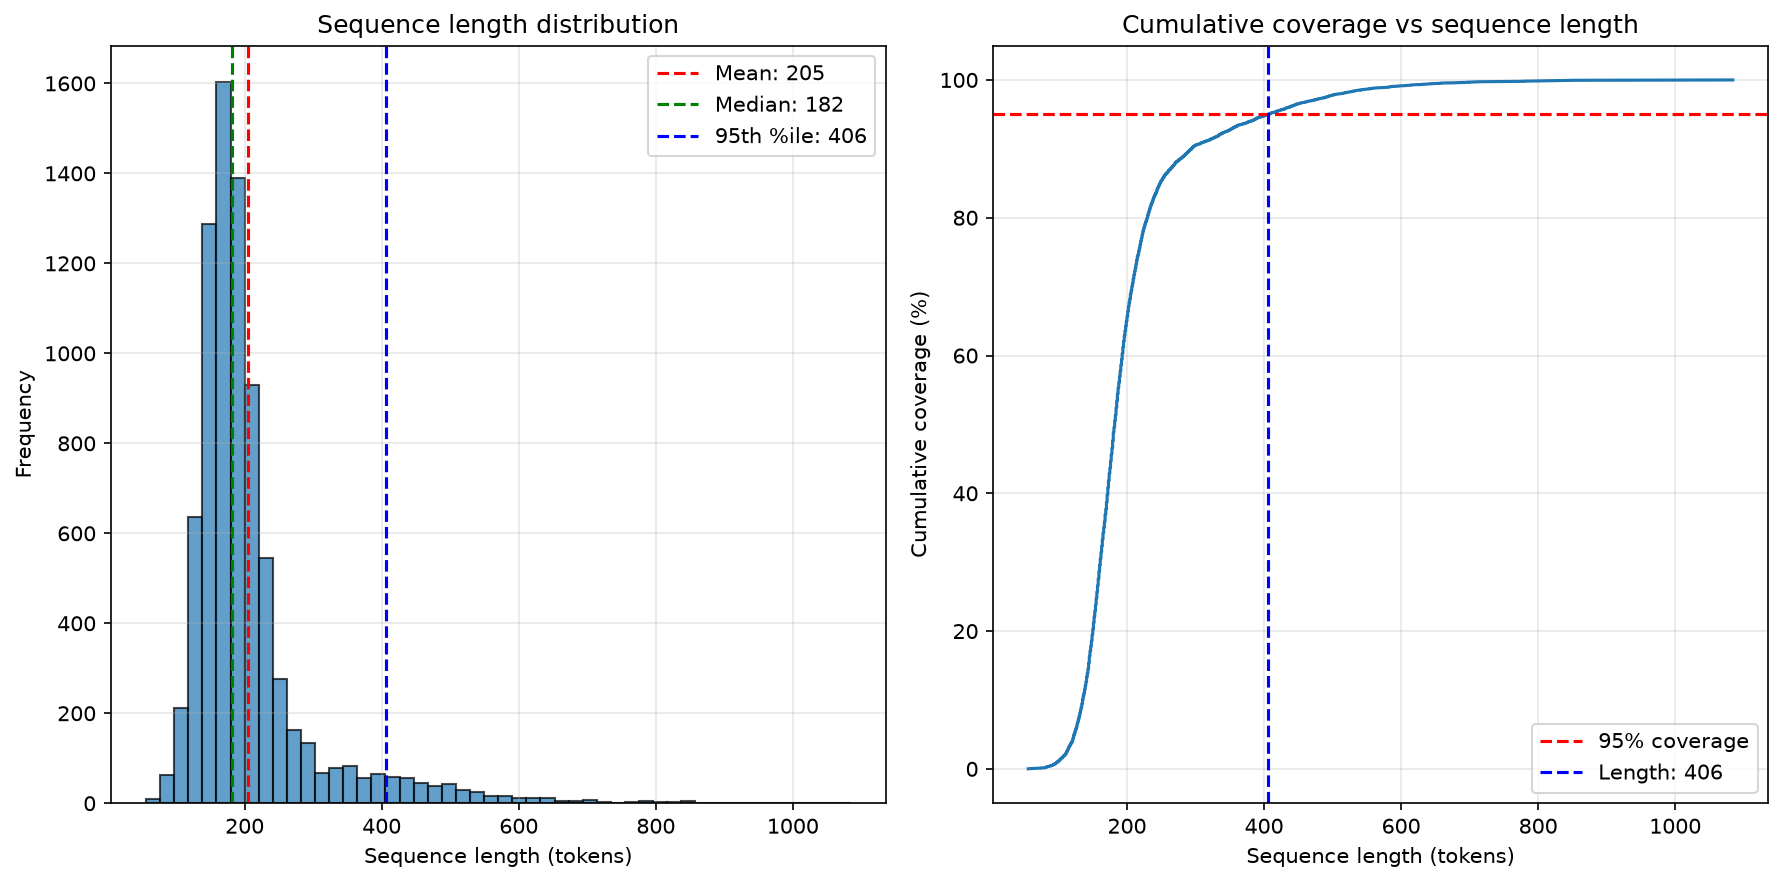

In [4]:
stats = load_artifact("dataset_statistics.json")
print(f"Stories: {stats['num_stories']:,} "
      f"(train {stats['train_size']:,} / val {stats['val_size']:,} / test {stats['test_size']:,})")
print(f"Vocabulary: {stats['vocab_size']:,} tokens, "
      f"coverage {stats['vocab_coverage']:.2f}%")
print(f"max_seq_len: {stats['max_seq_len']} "
      f"(95th percentile of lengths: {stats['length_stats']['percentile_95']:.0f})")

seq_fig = FIGURES / "sequence_length_analysis.png"
if seq_fig.exists():
    display(Image(filename=str(seq_fig)))

## Phase 4: Pre-training

The model is trained with a causal-LM objective using AdamW (beta2 = 0.95) and a
cosine schedule with warmup. The committed history records loss and perplexity over
5,000 steps; the figure shows both curves.

Total steps: 5,000
Final train loss/ppl: 1.843 / 6.31
Final val loss/ppl:   2.632 / 13.90
Best val loss:        2.608


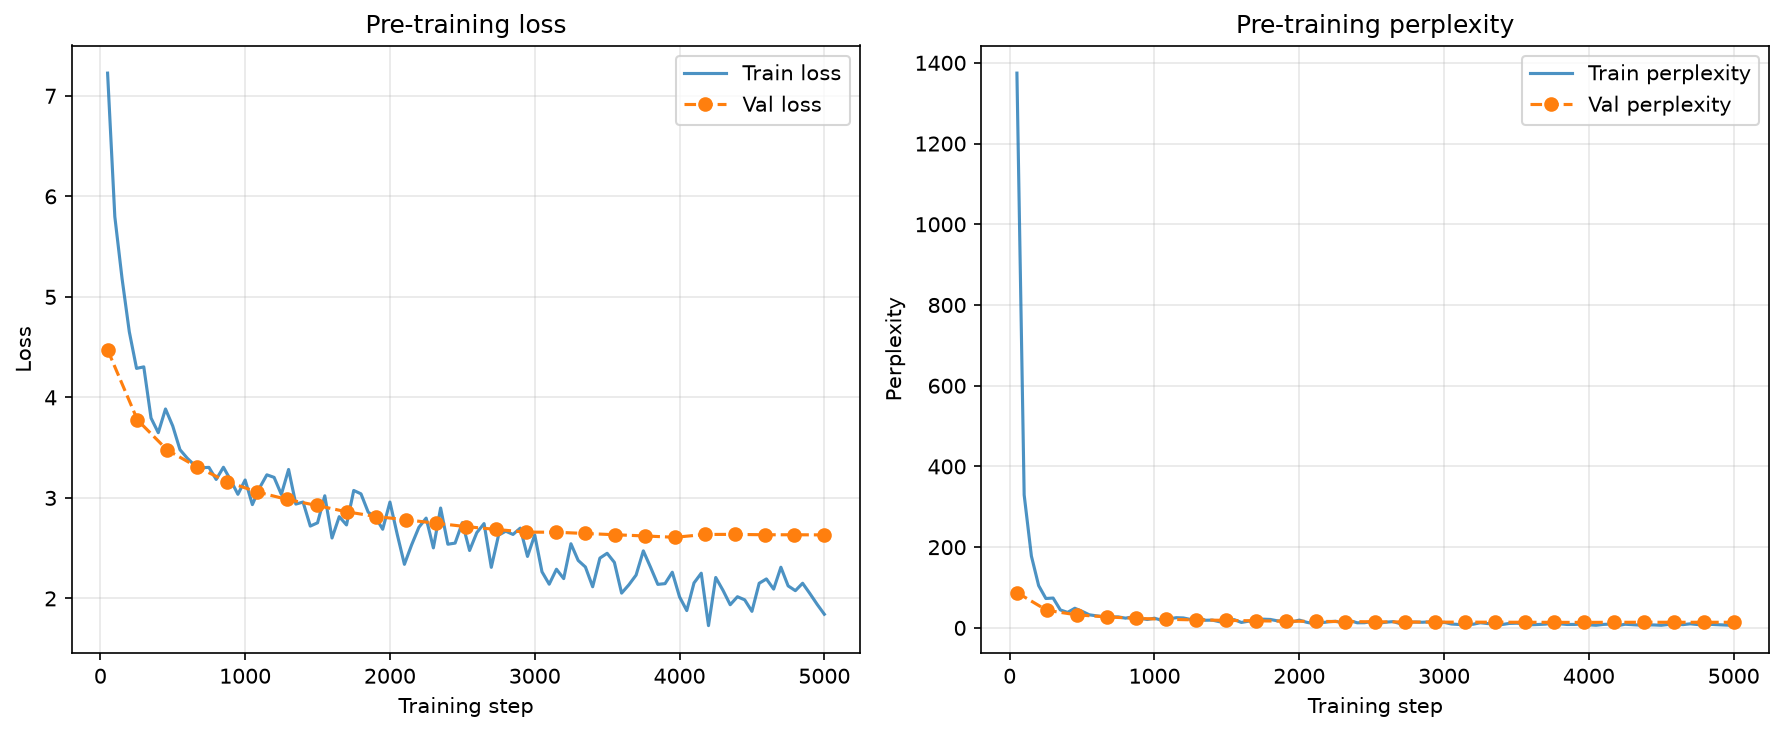

In [5]:
history = load_artifact("pretrain_history.json")
s = history["summary"]
print(f"Total steps: {s['total_steps']:,}")
print(f"Final train loss/ppl: {s['final_train_loss']:.3f} / {s['final_train_perplexity']:.2f}")
print(f"Final val loss/ppl:   {s['final_val_loss']:.3f} / {s['final_val_perplexity']:.2f}")
print(f"Best val loss:        {s['best_val_loss']:.3f}")

curves_fig = FIGURES / "training_curves.png"
if curves_fig.exists():
    display(Image(filename=str(curves_fig)))

## Phase 5: Generation

Given a trained checkpoint, the model generates continuations with configurable
decoding (greedy, temperature, top-k, top-p, repetition penalty). The cell below
runs only if a checkpoint is present locally (checkpoints are not committed).

In [6]:
samples = load_artifact("generation_samples.json")
cfg = samples["config"]
print(f"Committed samples from the reference run (temperature {cfg['temperature']}, "
      f"top_k {cfg['top_k']}, top_p {cfg['top_p']}):\n")
for g in samples["generations"]:
    print(f"Prompt: {g['prompt']}")
    print(g["generated_text"])
    print()

gen_model, gen_tokenizer = qp.load_model_and_tokenizer()
if gen_model is not None:
    print("Live generation from a local checkpoint:\n")
    config = qp.GenerationConfig(
        max_new_tokens=50, temperature=0.8, top_k=50, top_p=0.9,
        repetition_penalty=1.1, device="cpu",
    )
    for prompt in ["Once upon a time", "The little dog"]:
        print(f"Prompt: {prompt}")
        print(qp.generate(gen_model, gen_tokenizer, prompt, config))
        print()
else:
    print("No local checkpoint found; showing committed samples only. Run "
          "`python qwen3_pipeline.py` to train one, or "
          "`python qwen3_pipeline.py --interactive` for a prompt REPL.")

Committed samples from the reference run (temperature 0.8, top_k 50, top_p 0.9):

Prompt: Once upon a time
Once upon a time there was a little girl named Sarah. She loved to play outside in the park. One day, she saw a butterfly and wanted to catch it. She ran up to her mom and said," Mommy, this is so nice!" Her mom replied," Yes, it ' s a great

Prompt: One day, a little
One day, a little was walking through the park. It was cold and it was very cold. Suddenly, a big dog came and flew over to the house. The dog saw the dog and ran over to help. He got scared and tried to climb on the way home, but the dog was too fast. The dog

Prompt: There was a
There was a in the park. It was a perfect day and the sun was shining in the sky. The sun was shining and it looked so pretty. Suddenly, it stopped. A little boy with a big smile. He asked his mom why the boy looked at the rainbow. His mom smiled and said,"

Prompt: A boy and a girl
A boy and a girl of friends. They like to play in the park

Initialized Qwen3-small with 19.52M parameters
Loaded model (19.52M parameters) and tokenizer (7392 tokens)
Live generation from a local checkpoint:

Prompt: Once upon a time


Once upon a time there was a little girl named Jane. She loved to play outside in the garden and pick flowers. One day, she saw something in the grass and she decided to take it home. As she was walking through the garden, she heard an old man

Prompt: The little dog


The little dog in the park, and they like to run. One day, they see a big tree with lots of trees. They want to explore the park and find something special." Let ' s go and see!" said the little girl. So they



## Phase 6: Sentiment classification (frozen probe)

A lightweight head is trained over mean-pooled hidden states from the frozen base,
turning the pre-trained representations into a binary sentiment probe. The committed
metrics, 95% bootstrap confidence intervals, confusion matrix, and per-class figure
summarize test-set performance.

Frozen-probe sentiment (test set), with 95% bootstrap CIs:
Accuracy: 64.19%  CI [61.81, 66.63]
Macro-F1: 64.03%  CI [61.64, 66.55]
Negative P/R/F1: 69.96% / 63.17% / 66.39%
Positive P/R/F1: 58.28% / 65.48% / 61.67%
Best val macro-F1: 66.69%


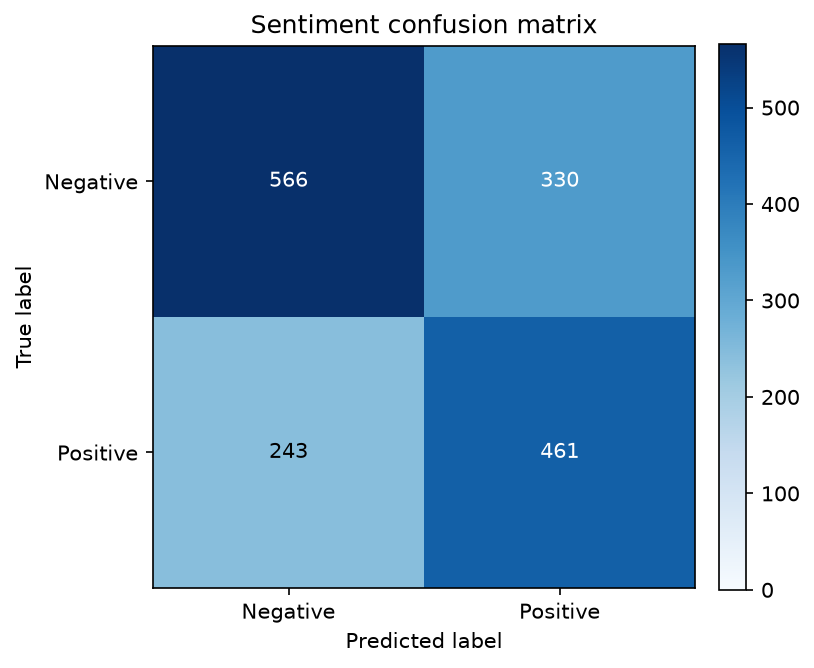

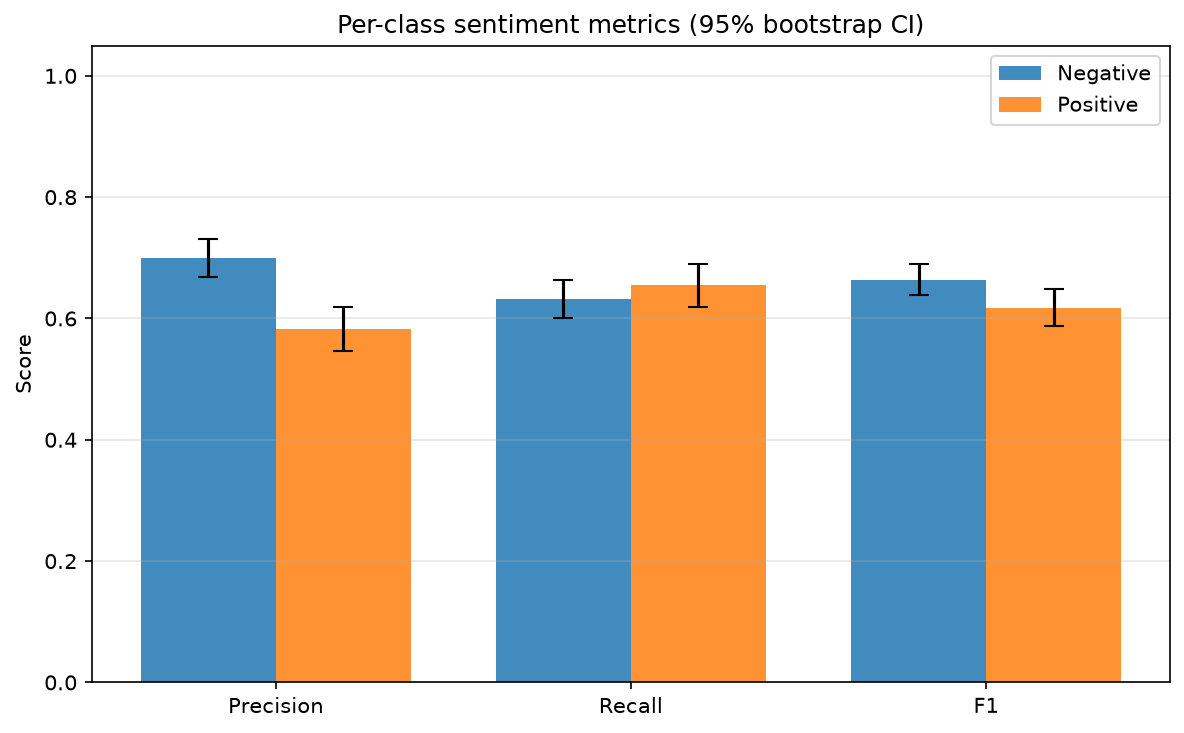

In [7]:
sent = load_artifact("sentiment_metrics.json")
ci = sent["confidence_intervals"]


def with_ci(key):
    """Format a metric as 'point% [lower, upper]' from the bootstrap CI block."""
    b = ci[key]
    return f"{sent[key]*100:.2f}%  CI [{b['lower']*100:.2f}, {b['upper']*100:.2f}]"


print("Frozen-probe sentiment (test set), with 95% bootstrap CIs:")
print(f"Accuracy: {with_ci('accuracy')}")
print(f"Macro-F1: {with_ci('macro_f1')}")
print(f"Negative P/R/F1: {sent['negative_precision']*100:.2f}% / "
      f"{sent['negative_recall']*100:.2f}% / {sent['negative_f1']*100:.2f}%")
print(f"Positive P/R/F1: {sent['positive_precision']*100:.2f}% / "
      f"{sent['positive_recall']*100:.2f}% / {sent['positive_f1']*100:.2f}%")
print(f"Best val macro-F1: {sent['best_val_macro_f1']*100:.2f}%")

for name in ("confusion_matrix_sentiment.png", "per_class_metrics.png"):
    fig = FIGURES / name
    if fig.exists():
        display(Image(filename=str(fig)))

## Phase 7: Baselines and comparison

A probe score means little in isolation. Here we place the frozen probe next to a
majority-class floor, a lexical baseline (TF-IDF plus logistic regression), and the
same model with its base fine-tuned rather than frozen. All four use the identical
test split. Rebuild the committed artifacts with `python qwen3_pipeline.py --baseline`
and `python qwen3_pipeline.py --finetune`.

Method                            Accuracy  Macro-F1
----------------------------------------------------
Majority class                      56.00%    35.90%
Frozen probe (ours)                 64.19%    64.03%
Fine-tuned base (ours)              83.00%    82.56%
TF-IDF + logistic regression        93.19%    93.04%

Fine-tuning lifts accuracy from 64.19% to 83.00% versus the frozen probe.


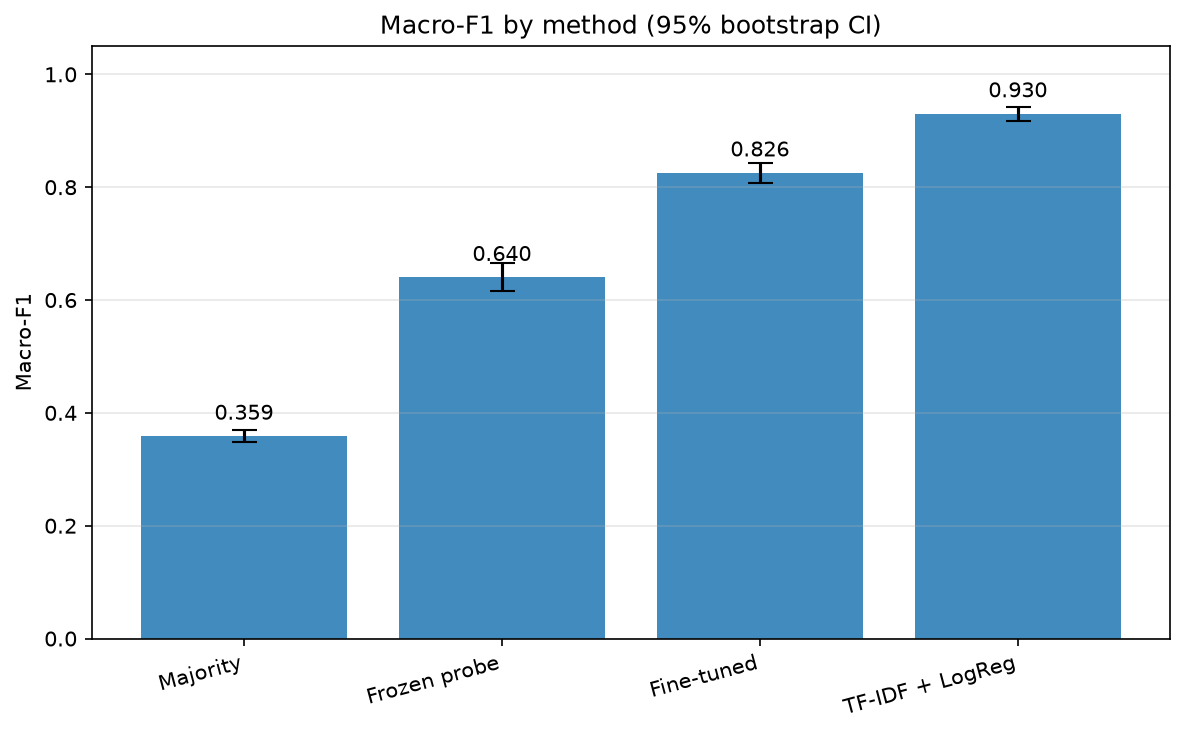

In [8]:
baselines = load_artifact("baseline_metrics.json")
finetuned = load_artifact("sentiment_finetuned_metrics.json")

rows = [
    ("Majority class", baselines["majority_class"]),
    ("Frozen probe (ours)", sent),
    ("Fine-tuned base (ours)", finetuned),
    ("TF-IDF + logistic regression", baselines["tfidf_logreg"]),
]

print(f"{'Method':<32}{'Accuracy':>10}{'Macro-F1':>10}")
print("-" * 52)
for name, m in rows:
    print(f"{name:<32}{m['accuracy']*100:>9.2f}%{m['macro_f1']*100:>9.2f}%")

print("\nFine-tuning lifts accuracy from "
      f"{sent['accuracy']*100:.2f}% to {finetuned['accuracy']*100:.2f}% versus the frozen probe.")

comp_fig = FIGURES / "baseline_comparison.png"
if comp_fig.exists():
    display(Image(filename=str(comp_fig)))

## Phase 8: Tokenizer coverage and error analysis

The tokenizer was fit on TinyStories, so it covers only part of the sentiment
vocabulary. A natural hypothesis is that out-of-vocabulary (OOV) tokens cap the
probe. The committed analysis tests that directly by correlating each sentence's
OOV rate with whether it was misclassified.

Tokenizer OOV rate on the sentiment corpus: 20.42% (coverage 79.58%)
Correlation between sentence OOV rate and error: -0.056
Mean OOV: correct 22.78% vs incorrect 21.50%

OOV bucket     Count  Accuracy  Mean OOV
----------------------------------------
0%                 4    50.00%     0.00%
(0,10%]          158    63.29%     7.92%
(10,25%]         935    61.93%    18.06%
>25%             503    68.79%    34.95%

OOV does not predict error at the sentence level, so vocabulary coverage is not the binding constraint; adaptation (fine-tuning) is.


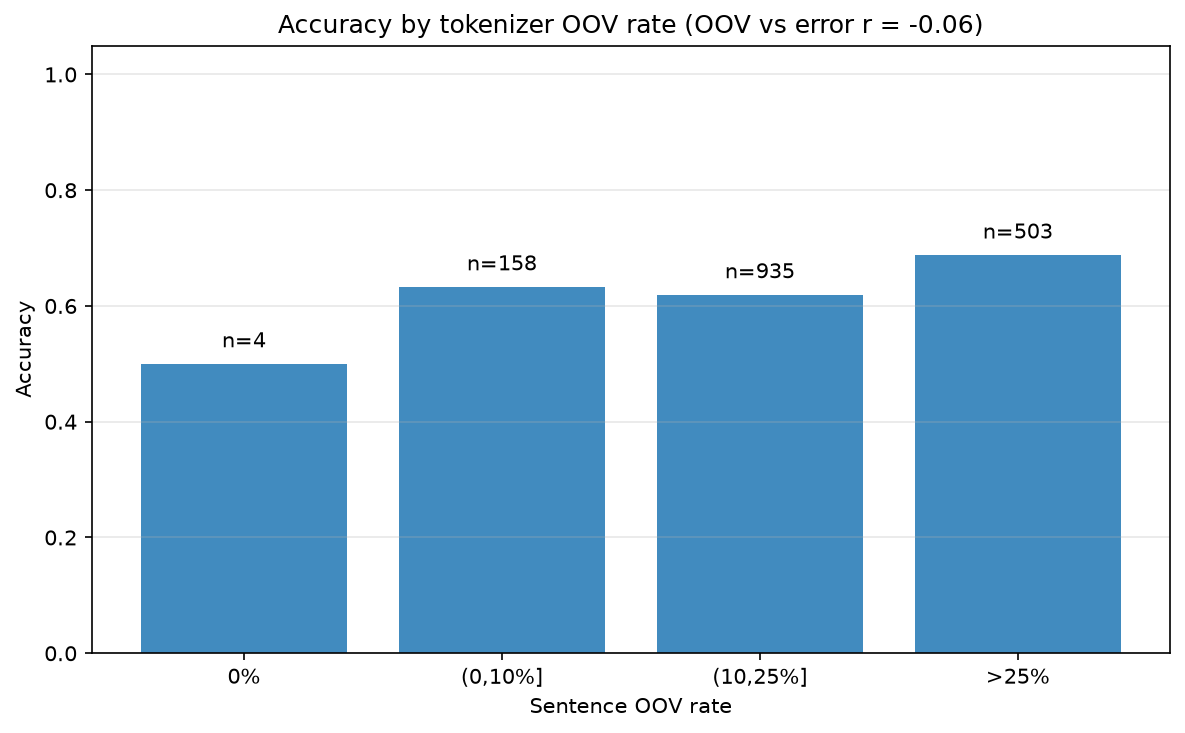

In [9]:
oov = load_artifact("sentiment_oov_error.json")
tok_oov = baselines["tokenizer_oov"]

print(f"Tokenizer OOV rate on the sentiment corpus: {tok_oov['oov_rate']:.2f}% "
      f"(coverage {tok_oov['coverage']:.2f}%)")
print(f"Correlation between sentence OOV rate and error: "
      f"{oov['correlation_oov_vs_error']:.3f}")
print(f"Mean OOV: correct {oov['mean_oov_correct']:.2f}% vs "
      f"incorrect {oov['mean_oov_incorrect']:.2f}%\n")

print(f"{'OOV bucket':<12}{'Count':>8}{'Accuracy':>10}{'Mean OOV':>10}")
print("-" * 40)
for b in oov["buckets"]:
    print(f"{b['range']:<12}{b['count']:>8}{b['accuracy']*100:>9.2f}%{b['mean_oov']:>9.2f}%")

print("\nOOV does not predict error at the sentence level, so vocabulary coverage is "
      "not the binding constraint; adaptation (fine-tuning) is.")

oov_fig = FIGURES / "accuracy_by_oov.png"
if oov_fig.exists():
    display(Image(filename=str(oov_fig)))

## Phase 9: Summary

- A 19.52M-parameter mini LLM (Qwen3-inspired), trained from scratch on 10,000 TinyStories.
- Word-level tokenizer with 7,392 tokens and 99.84% coverage.
- Pre-training reaches a final validation perplexity near 13.9.
- The frozen representations support a sentiment probe at 64.19% accuracy / 64.03%
  macro-F1, above a 56.00% majority-class floor.
- Fine-tuning the base raises accuracy to 83.00%, and OOV rate does not predict
  errors, so representation adaptation (not vocabulary coverage) is the main lever.

To reproduce end to end, run `python qwen3_pipeline.py` (or `--quick` for a fast
smoke test), then `--baseline`, `--finetune`, and `--figures-only`. See `README.md`
for the full command reference and `docs/report.tex` for the written analysis.